In [ ]:
import os

!wget https://smell.cs.columbia.edu/static/smell-dataset.tar.gz
!tar -xzf smell-dataset.tar.gz


zsh:1: command not found: wget
tar: smell-dataset.tar.gz: m: No such file or directory


In [ ]:
import os

SOURCE_DATASET_ROOT = "/Users/tonydemac/Downloads/olfactory_project/dataset"

print(os.path.exists(SOURCE_DATASET_ROOT))
print(os.listdir(SOURCE_DATASET_ROOT)[:5])

True
['2025-05-10_20-16-43', '2025-05-15_15-05-00', '2025-04-28_15-47-21', '2025-04-13_17-38-22', '2025-04-18_14-49-00']


In [ ]:
import os
import shutil
import json
import pandas as pd
from tqdm import tqdm

SOURCE_DATASET_ROOT = "/Users/tonydemac/Downloads/olfactory_project/dataset"
DEST_ROOT = 'ny_smells_local'

# --- NEW: Remove destination root to ensure a clean rebuild ---
if os.path.exists(DEST_ROOT):
    shutil.rmtree(DEST_ROOT)
# --- END NEW ---

# Create destination directories
os.makedirs(DEST_ROOT, exist_ok=True)
os.makedirs(os.path.join(DEST_ROOT, 'images'), exist_ok=True)
os.makedirs(os.path.join(DEST_ROOT, 'signals_raw'), exist_ok=True)

all_metadata_entries = []
image_count = 0
signal_count = 0

# Get all date-stamped directories
date_folders = sorted([d for d in os.listdir(SOURCE_DATASET_ROOT) if os.path.isdir(os.path.join(SOURCE_DATASET_ROOT, d)) and d != 'README'])

print(f"Processing {len(date_folders)} date folders...")

for date_folder in tqdm(date_folders, desc="Consolidating files"):
    current_date_path = os.path.join(SOURCE_DATASET_ROOT, date_folder)

    # --- NEW: Process session_info.json to get scene_type ---
    date_folder_scene_type = None
    session_info_path = os.path.join(current_date_path, 'session_info.json')
    if os.path.exists(session_info_path):
        try:
            with open(session_info_path, 'r') as f_sess:
                session_data = json.load(f_sess)
                date_folder_scene_type = session_data.get('location') # Assuming 'location' is the key for scene_type
        except json.JSONDecodeError:
            print(f"Warning: Could not decode JSON from {session_info_path}")
    # --- END NEW ---

    # Process metadata JSON files
    metadata_path = os.path.join(current_date_path, 'sample_metadata')
    if os.path.exists(metadata_path):
        for json_file in sorted(os.listdir(metadata_path)):
            if json_file.endswith('.json'):
                with open(os.path.join(metadata_path, json_file), 'r') as f:
                    data = json.load(f)
                    if date_folder_scene_type: # Add scene_type if found
                        data['scene_type'] = date_folder_scene_type
                    else: # If no scene_type found for the date folder, assign 'unknown'
                        data['scene_type'] = 'unknown'
                    all_metadata_entries.append(data)

    # Process RGB image files
    rgb_path = os.path.join(current_date_path, 'rgb')
    if os.path.exists(rgb_path):
        for img_file in sorted(os.listdir(rgb_path)):
            if img_file.endswith('.png'):
                src_img_path = os.path.join(rgb_path, img_file)
                dest_img_name = f"sample_{image_count:04d}.jpg" # Standardize naming
                dest_img_path = os.path.join(DEST_ROOT, 'images', dest_img_name)
                shutil.move(src_img_path, dest_img_path)
                image_count += 1

    # Process smellprint_npy signal files
    signals_path = os.path.join(current_date_path, 'smellprint_npy')
    if os.path.exists(signals_path):
        for signal_file in sorted(os.listdir(signals_path)):
            if signal_file.endswith('.npy'):
                src_signal_path = os.path.join(signals_path, signal_file)
                dest_signal_name = f"signal_{signal_count:04d}.npy" # Standardize naming
                dest_signal_path = os.path.join(DEST_ROOT, 'signals_raw', dest_signal_name)
                shutil.move(src_signal_path, dest_signal_path)
                signal_count += 1

# Create the consolidated metadata.csv
if all_metadata_entries:
    df_metadata = pd.DataFrame(all_metadata_entries)
    df_metadata.to_csv(os.path.join(DEST_ROOT, 'metadata.csv'), index=False)
    print(f"Created metadata.csv with {len(df_metadata)} entries, including 'scene_type'.")
else:
    print("No metadata JSON files found to consolidate.")

print(f"Moved {image_count} images to {DEST_ROOT}/images/")
print(f"Moved {signal_count} signals to {DEST_ROOT}/signals_raw/")

print(f"\nNew structure of '{DEST_ROOT}':")
!ls -F ny_smells_local/
!ls -F ny_smells_local/images/ | head -n 5
!ls -F ny_smells_local/signals_raw/ | head -n 5

Processing 60 date folders...


Consolidating files: 100%|██████████| 60/60 [00:01<00:00, 39.04it/s]


Created metadata.csv with 6934 entries, including 'scene_type'.
Moved 6934 images to ny_smells_local/images/
Moved 6934 signals to ny_smells_local/signals_raw/

New structure of 'ny_smells_local':
images/       metadata.csv  signals_raw/
sample_0000.jpg*
sample_0001.jpg*
sample_0002.jpg*
sample_0003.jpg*
sample_0004.jpg*
ls: stdout: Undefined error: 0
signal_0000.npy*
signal_0001.npy*
signal_0002.npy*
signal_0003.npy*
signal_0004.npy*
ls: stdout: Undefined error: 0


In [ ]:
import pandas as pd

# Load the processed metadata file
df = pd.read_csv("ny_smells_local/metadata.csv")

# Store the original row index as file_idx.
# This prevents mismatches after reset_index(),
# so sample_XXXX and signal_XXXX still refer to the correct files.
df["file_idx"] = df.index

# Split train / validation / test sets based on object_idx
unique_objects = df[["object_idx"]].drop_duplicates()

train_objs = unique_objects.sample(frac=0.8, random_state=42)
remaining_objs = unique_objects.drop(train_objs.index)

val_objs = remaining_objs.sample(frac=0.5, random_state=42)
test_objs = remaining_objs.drop(val_objs.index)

train_df = df[df["object_idx"].isin(train_objs["object_idx"])].reset_index(drop=True)
val_df = df[df["object_idx"].isin(val_objs["object_idx"])].reset_index(drop=True)
test_df = df[df["object_idx"].isin(test_objs["object_idx"])].reset_index(drop=True)

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train_df.head()

train: (5638, 11)
val: (592, 11)
test: (704, 11)


,object_idx,sample_start_idx,sample_end_idx,vision_idx,pid,temperature,humidity,global_id,dist_to_object_cm,scene_type,file_idx
0,0,3386,3548,3467,64.41,24.4,27.3,2025-04-12_16-59-24_0_0,0,CV Lab Lounge,0
1,0,3549,3711,3630,64.43,24.4,27.1,2025-04-12_16-59-24_1_0,0,CV Lab Lounge,1
2,50,57743,57901,57822,66.02,26.0,26.0,2025-04-12_16-59-24_100_50,0,CV Lab Lounge,3
3,50,57902,58059,57980,64.30,26.0,25.6,2025-04-12_16-59-24_101_50,0,CV Lab Lounge,4
4,51,58812,58970,58891,64.70,26.0,25.0,2025-04-12_16-59-24_102_51,0,CV Lab Lounge,5


In [ ]:
images, signals = next(iter(train_loader))
print(images.shape)
print(signals.shape)

torch.Size([8, 3, 224, 224])
torch.Size([8, 32, 1])


In [ ]:
# ============================================================
# Full Olfactory Training Pipeline in One Cell
# Object-level version:
# - Dataset returns object_idx
# - COIP uses object-level contrastive loss
# - Validation uses Object Recall@1 / Object Recall@5
# - OlfactoryEncoder uses MLP for [B, 32, 1] signal
# - VAE output matches real signal length
# - ViT freezes all layers except last N layers
# ============================================================

import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import ViTModel, ViTImageProcessor


# ============================================================
# 0. Config
# ============================================================

METADATA_CSV = "ny_smells_local/metadata.csv"
IMAGE_DIR = "ny_smells_local/images"
SIGNAL_DIR = "ny_smells_local/signals_raw"

RANDOM_SEED = 42

RUN_SMALL = True
TRAIN_LIMIT = 3000
VAL_LIMIT = 500

BATCH_SIZE = 8
NUM_WORKERS = 0

COIP_EPOCHS = 10
VAE_EPOCHS = 5
DENOISING_EPOCHS = 5

FREEZE_VIT = True
UNFREEZE_LAST_VIT_LAYERS = 2

IMAGE_LATENT_DIM = 512
SIGNAL_LATENT_DIM = 128

VIT_MODEL_NAME = "google/vit-base-patch16-224"


# ============================================================
# 1. Device
# ============================================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)


# ============================================================
# 2. Check files
# ============================================================

if not os.path.exists(METADATA_CSV):
    raise FileNotFoundError(
        f"Cannot find {METADATA_CSV}. "
        "You need to run the data preprocessing cell first."
    )

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Cannot find image directory: {IMAGE_DIR}")

if not os.path.exists(SIGNAL_DIR):
    raise FileNotFoundError(f"Cannot find signal directory: {SIGNAL_DIR}")

print("Metadata found:", METADATA_CSV)
print("Image dir found:", IMAGE_DIR)
print("Signal dir found:", SIGNAL_DIR)


# ============================================================
# 3. Load metadata and split train / val / test
# ============================================================

df = pd.read_csv(METADATA_CSV)

# Preserve original file index.
# sample_0000.jpg corresponds to file_idx = 0.
# signal_0000.npy corresponds to file_idx = 0.
df["file_idx"] = df.index

if "object_idx" not in df.columns:
    raise ValueError(
        "metadata.csv does not contain 'object_idx'. "
        "Please check your preprocessing code."
    )

unique_objects = df[["object_idx"]].drop_duplicates()

train_objs = unique_objects.sample(frac=0.8, random_state=RANDOM_SEED)
remaining_objs = unique_objects.drop(train_objs.index)

val_objs = remaining_objs.sample(frac=0.5, random_state=RANDOM_SEED)
test_objs = remaining_objs.drop(val_objs.index)

train_df = df[df["object_idx"].isin(train_objs["object_idx"])].reset_index(drop=True)
val_df = df[df["object_idx"].isin(val_objs["object_idx"])].reset_index(drop=True)
test_df = df[df["object_idx"].isin(test_objs["object_idx"])].reset_index(drop=True)

if RUN_SMALL:
    train_df = train_df.sample(
        n=min(TRAIN_LIMIT, len(train_df)),
        random_state=RANDOM_SEED
    ).reset_index(drop=True)

    val_df = val_df.sample(
        n=min(VAL_LIMIT, len(val_df)),
        random_state=RANDOM_SEED
    ).reset_index(drop=True)

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))


# ============================================================
# 4. Dataset
# ============================================================

class OlfactoryMatrixDataset(Dataset):
    def __init__(
        self,
        metadata_df,
        image_dir,
        signals_dir,
        processor,
        global_min=None,
        global_max=None
    ):
        self.df = metadata_df.copy()

        if "file_idx" in self.df.columns:
            self.indices = self.df["file_idx"].tolist()
        else:
            self.indices = self.df.index.tolist()

        self.image_dir = image_dir
        self.signals_dir = signals_dir
        self.processor = processor
        self.global_min = global_min
        self.global_max = global_max

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        file_idx = int(self.indices[idx])

        img_path = os.path.join(self.image_dir, f"sample_{file_idx:04d}.jpg")
        sig_path = os.path.join(self.signals_dir, f"signal_{file_idx:04d}.npy")

        if not os.path.exists(img_path):
            raise FileNotFoundError(f"Image not found: {img_path}")

        if not os.path.exists(sig_path):
            raise FileNotFoundError(f"Signal not found: {sig_path}")

        # Load image
        image = Image.open(img_path).convert("RGB")
        pixel_values = self.processor(
            image,
            return_tensors="pt"
        ).pixel_values.squeeze(0)

        # Load signal
        matrix = np.load(sig_path)

        if matrix.ndim == 1:
            matrix = matrix.reshape(1, -1)
        elif matrix.ndim == 0:
            matrix = np.array([[matrix]])

        signal = torch.tensor(matrix, dtype=torch.float32)

        if signal.ndim != 2:
            raise ValueError(
                f"Signal should be 2D, got shape {signal.shape}. "
                f"Problem file: {sig_path}"
            )

        # Convert [time, 32] to [32, time]
        if signal.shape[1] == 32 and signal.shape[0] != 32:
            signal = signal.transpose(0, 1)

        # Already [32, time]
        elif signal.shape[0] == 32:
            pass

        else:
            raise ValueError(
                f"Signal shape is {signal.shape}, expected [32, time] or [time, 32]. "
                f"Problem file: {sig_path}"
            )

        # Normalize
        if self.global_min is not None and self.global_max is not None:
            signal = (signal - self.global_min) / (
                self.global_max - self.global_min + 1e-8
            )

        object_idx = int(self.df.iloc[idx]["object_idx"])

        return pixel_values, signal, object_idx


# ============================================================
# 5. Model definitions
# ============================================================

class VisionEncoder(nn.Module):
    def __init__(self, latent_dim=512, model_name=VIT_MODEL_NAME):
        super().__init__()

        self.backbone = ViTModel.from_pretrained(model_name)

        self.projection = nn.Sequential(
            nn.Linear(self.backbone.config.hidden_size, 1024),
            nn.GELU(),
            nn.Linear(1024, latent_dim),
            nn.LayerNorm(latent_dim)
        )

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]
        latent_vector = self.projection(cls_token)
        return latent_vector


class OlfactoryEncoder(nn.Module):
    def __init__(self, latent_dim=512, num_sensors=32, signal_length=1):
        super().__init__()

        input_dim = num_sensors * signal_length

        self.net = nn.Sequential(
            nn.Flatten(),  # [B, 32, signal_length] -> [B, 32 * signal_length]

            nn.Linear(input_dim, 256),
            nn.GELU(),
            nn.LayerNorm(256),
            nn.Dropout(0.1),

            nn.Linear(256, 512),
            nn.GELU(),
            nn.LayerNorm(512),
            nn.Dropout(0.1),

            nn.Linear(512, latent_dim),
            nn.LayerNorm(latent_dim)
        )

    def forward(self, signal):
        return self.net(signal)


class COIPModel(nn.Module):
    def __init__(self, vision_encoder, olfactory_encoder):
        super().__init__()

        self.vision_encoder = vision_encoder
        self.olfactory_encoder = olfactory_encoder

        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

    def forward(self, pixel_values, signals):
        image_features = self.vision_encoder(pixel_values)
        signal_features = self.olfactory_encoder(signals)

        image_features = F.normalize(image_features, dim=-1)
        signal_features = F.normalize(signal_features, dim=-1)

        logit_scale = self.logit_scale.exp().clamp(max=100)

        return image_features, signal_features, logit_scale


class SignalVAE(nn.Module):
    def __init__(self, latent_dim=128, signal_length=1):
        super().__init__()

        self.latent_dim = latent_dim
        self.signal_length = signal_length

        self.encoder = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=1),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, 128 * signal_length)

        self.decoder = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(64, 32, kernel_size=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.squeeze(-1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(z.size(0), 128, self.signal_length)
        x = self.decoder(x)

        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)

        return recon, mu, logvar


class LatentDenoisingModel(nn.Module):
    def __init__(self, latent_dim=128, cond_dim=512):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim + cond_dim + 1, 512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.GELU(),
            nn.Linear(512, latent_dim)
        )

    def forward(self, z_t, t, condition):
        if t.dim() == 1:
            t = t.unsqueeze(-1)

        t = t.float().to(z_t.device)
        condition = condition.to(z_t.device)

        x = torch.cat([z_t, t, condition], dim=-1)

        return self.net(x)


# ============================================================
# 6. Processor and temporary dataset
# ============================================================

processor = ViTImageProcessor.from_pretrained(VIT_MODEL_NAME)

temp_train_dataset = OlfactoryMatrixDataset(
    train_df,
    image_dir=IMAGE_DIR,
    signals_dir=SIGNAL_DIR,
    processor=processor,
    global_min=None,
    global_max=None
)

temp_train_loader = DataLoader(
    temp_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)


# ============================================================
# 7. Signal normalization
# ============================================================

def calculate_sensor_constants(loader):
    global_min = None
    global_max = None

    for _, signals, _ in tqdm(loader, desc="Calculating signal min/max"):
        batch_min = signals.amin(dim=(0, 2))
        batch_max = signals.amax(dim=(0, 2))

        if global_min is None:
            global_min = batch_min
            global_max = batch_max
        else:
            global_min = torch.minimum(global_min, batch_min)
            global_max = torch.maximum(global_max, batch_max)

    global_min = global_min.view(32, 1)
    global_max = global_max.view(32, 1)

    return global_min, global_max


global_min, global_max = calculate_sensor_constants(temp_train_loader)

torch.save(
    {"min": global_min, "max": global_max},
    "sensor_metadata.pt"
)

print("Saved sensor_metadata.pt")


train_dataset = OlfactoryMatrixDataset(
    train_df,
    image_dir=IMAGE_DIR,
    signals_dir=SIGNAL_DIR,
    processor=processor,
    global_min=global_min,
    global_max=global_max
)

val_dataset = OlfactoryMatrixDataset(
    val_df,
    image_dir=IMAGE_DIR,
    signals_dir=SIGNAL_DIR,
    processor=processor,
    global_min=global_min,
    global_max=global_max
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

sample_images, sample_signals, sample_object_ids = next(iter(train_loader))

print("Sample image batch shape:", sample_images.shape)
print("Sample signal batch shape:", sample_signals.shape)
print("Sample object ids shape:", sample_object_ids.shape)

SIGNAL_LENGTH = sample_signals.shape[-1]

print("Detected SIGNAL_LENGTH:", SIGNAL_LENGTH)


# ============================================================
# 8. COIP object-level training
# ============================================================

def object_level_contrastive_loss(logits, object_ids):
    """
    logits: [B, B]
    object_ids: [B]

    All samples with the same object_idx are treated as positives.
    """

    object_ids = object_ids.to(logits.device)

    positive_mask = object_ids.unsqueeze(0) == object_ids.unsqueeze(1)
    positive_mask = positive_mask.float()

    log_probs = F.log_softmax(logits, dim=1)

    positive_count = positive_mask.sum(dim=1).clamp(min=1)

    loss = -(positive_mask * log_probs).sum(dim=1) / positive_count

    return loss.mean()


def get_coip_optimizer(model, lr=2e-5, weight_decay=0.1):
    decay = []
    no_decay = []

    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue

        if name == "logit_scale" or name.endswith(".bias"):
            no_decay.append(param)
        else:
            decay.append(param)

    return torch.optim.AdamW(
        [
            {"params": decay, "weight_decay": weight_decay},
            {"params": no_decay, "weight_decay": 0.0},
        ],
        lr=lr
    )


@torch.no_grad()
def validate_object_retrieval(model, val_loader, device):
    model.eval()

    all_img_emb = []
    all_sig_emb = []
    all_object_ids = []

    for images, signals, object_ids in tqdm(val_loader, desc="Validating object-level retrieval"):
        images = images.to(device)
        signals = signals.to(device)

        img_emb, sig_emb, _ = model(images, signals)

        all_img_emb.append(img_emb.cpu())
        all_sig_emb.append(sig_emb.cpu())
        all_object_ids.append(object_ids.cpu())

    all_img_emb = torch.cat(all_img_emb, dim=0)
    all_sig_emb = torch.cat(all_sig_emb, dim=0)
    all_object_ids = torch.cat(all_object_ids, dim=0)

    similarity = all_img_emb @ all_sig_emb.T
    ranking = similarity.argsort(dim=1, descending=True)

    correct_at_1 = 0
    correct_at_5 = 0

    for i in range(similarity.size(0)):
        true_object = all_object_ids[i]

        top1_idx = ranking[i, 0]
        top5_idx = ranking[i, :5]

        if all_object_ids[top1_idx] == true_object:
            correct_at_1 += 1

        if (all_object_ids[top5_idx] == true_object).any():
            correct_at_5 += 1

    recall_at_1 = correct_at_1 / similarity.size(0)
    recall_at_5 = correct_at_5 / similarity.size(0)

    return recall_at_1, recall_at_5


def train_coip(model, train_loader, val_loader, optimizer, device, epochs=1):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        pbar = tqdm(train_loader, desc=f"COIP Epoch {epoch+1}/{epochs}")

        for images, signals, object_ids in pbar:
            images = images.to(device)
            signals = signals.to(device)
            object_ids = object_ids.to(device)

            img_emb, sig_emb, logit_scale = model(images, signals)

            logits_per_image = logit_scale * (img_emb @ sig_emb.T)
            logits_per_signal = logits_per_image.T

            loss_img = object_level_contrastive_loss(
                logits_per_image,
                object_ids
            )

            loss_sig = object_level_contrastive_loss(
                logits_per_signal,
                object_ids
            )

            loss = (loss_img + loss_sig) / 2

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            pbar.set_postfix({"loss": loss.item()})

        avg_loss = total_loss / len(train_loader)

        obj_r1, obj_r5 = validate_object_retrieval(
            model,
            val_loader,
            device
        )

        print(
            f"COIP Epoch {epoch+1}: "
            f"loss={avg_loss:.4f}, "
            f"Object Recall@1={obj_r1:.4f}, "
            f"Object Recall@5={obj_r5:.4f}"
        )

        if device.type == "mps":
            torch.mps.empty_cache()

    torch.save(model.state_dict(), "coip_model.pt")
    print("Saved coip_model.pt")


vision_encoder = VisionEncoder(
    latent_dim=IMAGE_LATENT_DIM,
    model_name=VIT_MODEL_NAME
).to(device)

olfactory_encoder = OlfactoryEncoder(
    latent_dim=IMAGE_LATENT_DIM,
    num_sensors=32,
    signal_length=SIGNAL_LENGTH
).to(device)

coip_model = COIPModel(
    vision_encoder=vision_encoder,
    olfactory_encoder=olfactory_encoder
).to(device)


# ============================================================
# ViT fine-tuning control
# ============================================================

if FREEZE_VIT:
    print(
        f"Freezing ViT backbone, unfreezing last "
        f"{UNFREEZE_LAST_VIT_LAYERS} transformer layer(s)..."
    )

    # Freeze all ViT parameters first
    for param in coip_model.vision_encoder.backbone.parameters():
        param.requires_grad = False

    # Unfreeze the last N ViT encoder layers
    if UNFREEZE_LAST_VIT_LAYERS > 0:
        for layer in coip_model.vision_encoder.backbone.encoder.layer[-UNFREEZE_LAST_VIT_LAYERS:]:
            for param in layer.parameters():
                param.requires_grad = True

    # Keep projection head trainable
    for param in coip_model.vision_encoder.projection.parameters():
        param.requires_grad = True

else:
    print("Full ViT backbone is trainable.")


trainable_params = sum(
    p.numel() for p in coip_model.parameters() if p.requires_grad
)
total_params = sum(
    p.numel() for p in coip_model.parameters()
)

print(f"Trainable params: {trainable_params:,}")
print(f"Total params: {total_params:,}")
print(f"Trainable ratio: {trainable_params / total_params:.2%}")


coip_optimizer = get_coip_optimizer(
    coip_model,
    lr=2e-5,
    weight_decay=0.1
)

train_coip(
    model=coip_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=coip_optimizer,
    device=device,
    epochs=COIP_EPOCHS
)


# ============================================================
# 9. VAE training
# ============================================================

def vae_loss(recon_x, x, mu, logvar, beta=1e-4):
    if recon_x.shape != x.shape:
        raise ValueError(
            f"VAE output shape {recon_x.shape} does not match target shape {x.shape}"
        )

    recon_loss = F.mse_loss(recon_x, x, reduction="mean")

    kl_loss = -0.5 * torch.mean(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    loss = recon_loss + beta * kl_loss

    return loss, recon_loss, kl_loss


def train_vae(vae, train_loader, optimizer, device, epochs=1):
    for epoch in range(epochs):
        vae.train()

        total_loss = 0
        total_recon = 0
        total_kl = 0

        pbar = tqdm(train_loader, desc=f"VAE Epoch {epoch+1}/{epochs}")

        for _, signals, _ in pbar:
            signals = signals.to(device)

            recon, mu, logvar = vae(signals)

            loss, recon_loss, kl_loss = vae_loss(
                recon,
                signals,
                mu,
                logvar
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon_loss.item()
            total_kl += kl_loss.item()

            pbar.set_postfix({
                "loss": loss.item(),
                "recon": recon_loss.item(),
                "kl": kl_loss.item()
            })

        print(
            f"VAE Epoch {epoch+1}: "
            f"loss={total_loss/len(train_loader):.4f}, "
            f"recon={total_recon/len(train_loader):.4f}, "
            f"kl={total_kl/len(train_loader):.4f}"
        )

        if device.type == "mps":
            torch.mps.empty_cache()

    torch.save(vae.state_dict(), "signal_vae.pt")
    print("Saved signal_vae.pt")


vae = SignalVAE(
    latent_dim=SIGNAL_LATENT_DIM,
    signal_length=SIGNAL_LENGTH
).to(device)

vae_optimizer = torch.optim.AdamW(
    vae.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

train_vae(
    vae=vae,
    train_loader=train_loader,
    optimizer=vae_optimizer,
    device=device,
    epochs=VAE_EPOCHS
)


# ============================================================
# 10. Latent denoising training
# ============================================================

def add_noise_to_latent(z, t):
    noise = torch.randn_like(z)
    z_t = (1 - t) * z + t * noise

    return z_t, noise


def train_denoising_model(
    denoising_model,
    vae,
    coip_model,
    train_loader,
    optimizer,
    device,
    epochs=1
):
    vae.eval()
    coip_model.eval()

    for epoch in range(epochs):
        denoising_model.train()
        total_loss = 0

        pbar = tqdm(train_loader, desc=f"Denoising Epoch {epoch+1}/{epochs}")

        for images, signals, _ in pbar:
            images = images.to(device)
            signals = signals.to(device)

            with torch.no_grad():
                image_features, _, _ = coip_model(images, signals)

                mu, logvar = vae.encode(signals)
                z = mu

            batch_size = z.size(0)
            t = torch.rand(batch_size, 1, device=device)

            z_t, noise = add_noise_to_latent(z, t)

            predicted_noise = denoising_model(
                z_t,
                t,
                image_features
            )

            loss = F.mse_loss(predicted_noise, noise)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({"loss": loss.item()})

        print(
            f"Denoising Epoch {epoch+1}: "
            f"loss={total_loss/len(train_loader):.4f}"
        )

        if device.type == "mps":
            torch.mps.empty_cache()

    torch.save(denoising_model.state_dict(), "latent_denoising_model.pt")
    print("Saved latent_denoising_model.pt")


denoising_model = LatentDenoisingModel(
    latent_dim=SIGNAL_LATENT_DIM,
    cond_dim=IMAGE_LATENT_DIM
).to(device)

denoising_optimizer = torch.optim.AdamW(
    denoising_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

train_denoising_model(
    denoising_model=denoising_model,
    vae=vae,
    coip_model=coip_model,
    train_loader=train_loader,
    optimizer=denoising_optimizer,
    device=device,
    epochs=DENOISING_EPOCHS
)


# ============================================================
# 11. Done
# ============================================================

print("All training finished.")
print("Saved files:")
print("- sensor_metadata.pt")
print("- coip_model.pt")
print("- signal_vae.pt")
print("- latent_denoising_model.pt")

Using device: mps
Metadata found: ny_smells_local/metadata.csv
Image dir found: ny_smells_local/images
Signal dir found: ny_smells_local/signals_raw
Train samples: 3000
Val samples: 500
Test samples: 704


Calculating signal min/max: 100%|██████████| 375/375 [01:33<00:00,  4.03it/s]


Saved sensor_metadata.pt
Sample image batch shape: torch.Size([8, 3, 224, 224])
Sample signal batch shape: torch.Size([8, 32, 1])
Sample object ids shape: torch.Size([8])
Detected SIGNAL_LENGTH: 1


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 15491.86it/s]
[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Freezing ViT backbone, unfreezing last 2 transformer layer(s)...
Trainable params: 15,894,273
Total params: 88,107,777
Trainable ratio: 18.04%


...

Denoising Epoch 3: loss=0.6434


Denoising Epoch 4/5: 100%|██████████| 375/375 [02:37<00:00,  2.37it/s, loss=0.596]


Denoising Epoch 4: loss=0.5578


Denoising Epoch 5/5: 100%|██████████| 375/375 [02:38<00:00,  2.37it/s, loss=0.522]

Denoising Epoch 5: loss=0.4842
Saved latent_denoising_model.pt
All training finished.
Saved files:
- sensor_metadata.pt
- coip_model.pt
- signal_vae.pt
- latent_denoising_model.pt


In [ ]:
import os
import torch
import pandas as pd
from torch.utils.data import DataLoader
from transformers import ViTImageProcessor


# ============================================================
# 0. Config
# ============================================================

METADATA_CSV = "ny_smells_local/metadata.csv"
IMAGE_DIR = "ny_smells_local/images"
SIGNAL_DIR = "ny_smells_local/signals_raw"

RANDOM_SEED = 42

RUN_SMALL = True
TRAIN_LIMIT = 3000
VAL_LIMIT = 500

BATCH_SIZE = 8
NUM_WORKERS = 0

COIP_EPOCHS = 10
VAE_EPOCHS = 5
DENOISING_EPOCHS = 5

IMAGE_LATENT_DIM = 512
SIGNAL_LATENT_DIM = 128

VIT_MODEL_NAME = "google/vit-base-patch16-224"

FREEZE_VIT = True
UNFREEZE_LAST_VIT_LAYERS = 2

SAVE_DIR = "."


# ============================================================
# 1. Device
# ============================================================

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)


# ============================================================
# 2. Check files
# ============================================================

if not os.path.exists(METADATA_CSV):
    raise FileNotFoundError(f"Cannot find {METADATA_CSV}")

if not os.path.exists(IMAGE_DIR):
    raise FileNotFoundError(f"Cannot find {IMAGE_DIR}")

if not os.path.exists(SIGNAL_DIR):
    raise FileNotFoundError(f"Cannot find {SIGNAL_DIR}")

print("Metadata found:", METADATA_CSV)
print("Image dir found:", IMAGE_DIR)
print("Signal dir found:", SIGNAL_DIR)


# ============================================================
# 3. Load metadata and split data
# ============================================================

df = pd.read_csv(METADATA_CSV)

# Preserve original file index
df["file_idx"] = df.index

unique_objects = df[["object_idx"]].drop_duplicates()

train_objs = unique_objects.sample(frac=0.8, random_state=RANDOM_SEED)
remaining_objs = unique_objects.drop(train_objs.index)

val_objs = remaining_objs.sample(frac=0.5, random_state=RANDOM_SEED)
test_objs = remaining_objs.drop(val_objs.index)

train_df = df[df["object_idx"].isin(train_objs["object_idx"])].reset_index(drop=True)
val_df = df[df["object_idx"].isin(val_objs["object_idx"])].reset_index(drop=True)
test_df = df[df["object_idx"].isin(test_objs["object_idx"])].reset_index(drop=True)

if RUN_SMALL:
    train_df = train_df.sample(
        n=min(TRAIN_LIMIT, len(train_df)),
        random_state=RANDOM_SEED
    ).reset_index(drop=True)

    val_df = val_df.sample(
        n=min(VAL_LIMIT, len(val_df)),
        random_state=RANDOM_SEED
    ).reset_index(drop=True)

print("Train samples:", len(train_df))
print("Val samples:", len(val_df))
print("Test samples:", len(test_df))


# ============================================================
# 4. Processor
# ============================================================

processor = ViTImageProcessor.from_pretrained(VIT_MODEL_NAME)


# ============================================================
# 5. Temporary dataset for signal normalization
# ============================================================

temp_train_dataset = OlfactoryMatrixDataset(
    train_df,
    image_dir=IMAGE_DIR,
    signals_dir=SIGNAL_DIR,
    processor=processor,
    global_min=None,
    global_max=None
)

temp_train_loader = DataLoader(
    temp_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

global_min, global_max = calculate_sensor_constants(temp_train_loader)

torch.save(
    {"min": global_min, "max": global_max},
    os.path.join(SAVE_DIR, "sensor_metadata.pt")
)

print("Saved sensor_metadata.pt")


# ============================================================
# 6. Final datasets and loaders
# ============================================================

train_dataset = OlfactoryMatrixDataset(
    train_df,
    image_dir=IMAGE_DIR,
    signals_dir=SIGNAL_DIR,
    processor=processor,
    global_min=global_min,
    global_max=global_max
)

val_dataset = OlfactoryMatrixDataset(
    val_df,
    image_dir=IMAGE_DIR,
    signals_dir=SIGNAL_DIR,
    processor=processor,
    global_min=global_min,
    global_max=global_max
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

sample_images, sample_signals, sample_object_ids = next(iter(train_loader))

print("Sample image batch shape:", sample_images.shape)
print("Sample signal batch shape:", sample_signals.shape)
print("Sample object ids shape:", sample_object_ids.shape)

SIGNAL_LENGTH = sample_signals.shape[-1]

print("Detected SIGNAL_LENGTH:", SIGNAL_LENGTH)


# ============================================================
# 7. Build COIP model
# ============================================================

vision_encoder = VisionEncoder(
    latent_dim=IMAGE_LATENT_DIM,
    model_name=VIT_MODEL_NAME
).to(device)

olfactory_encoder = OlfactoryEncoder(
    latent_dim=IMAGE_LATENT_DIM,
    num_sensors=32,
    signal_length=SIGNAL_LENGTH
).to(device)

coip_model = COIPModel(
    vision_encoder=vision_encoder,
    olfactory_encoder=olfactory_encoder
).to(device)


# ============================================================
# 8. Freeze ViT except last N layers
# ============================================================

if FREEZE_VIT:
    print(
        f"Freezing ViT backbone, unfreezing last "
        f"{UNFREEZE_LAST_VIT_LAYERS} transformer layer(s)..."
    )

    for param in coip_model.vision_encoder.backbone.parameters():
        param.requires_grad = False

    if UNFREEZE_LAST_VIT_LAYERS > 0:
        for layer in coip_model.vision_encoder.backbone.encoder.layer[-UNFREEZE_LAST_VIT_LAYERS:]:
            for param in layer.parameters():
                param.requires_grad = True

    for param in coip_model.vision_encoder.projection.parameters():
        param.requires_grad = True

else:
    print("Full ViT backbone is trainable.")


trainable_params = sum(
    p.numel() for p in coip_model.parameters() if p.requires_grad
)

total_params = sum(
    p.numel() for p in coip_model.parameters()
)

print(f"Trainable params: {trainable_params:,}")
print(f"Total params: {total_params:,}")
print(f"Trainable ratio: {trainable_params / total_params:.2%}")


# ============================================================
# 9. Train COIP
# ============================================================

coip_optimizer = get_coip_optimizer(
    coip_model,
    lr=2e-5,
    weight_decay=0.1
)

coip_history = train_coip(
    model=coip_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=coip_optimizer,
    device=device,
    epochs=COIP_EPOCHS
)

torch.save(
    coip_model.state_dict(),
    os.path.join(SAVE_DIR, "coip_model.pt")
)

print("Saved coip_model.pt")


# ============================================================
# 10. Train VAE
# ============================================================

vae = SignalVAE(
    latent_dim=SIGNAL_LATENT_DIM,
    signal_length=SIGNAL_LENGTH
).to(device)

vae_optimizer = torch.optim.AdamW(
    vae.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

vae_history = train_vae(
    vae=vae,
    train_loader=train_loader,
    optimizer=vae_optimizer,
    device=device,
    epochs=VAE_EPOCHS
)

torch.save(
    vae.state_dict(),
    os.path.join(SAVE_DIR, "signal_vae.pt")
)

print("Saved signal_vae.pt")


# ============================================================
# 11. Train latent denoising model
# ============================================================

denoising_model = LatentDenoisingModel(
    latent_dim=SIGNAL_LATENT_DIM,
    cond_dim=IMAGE_LATENT_DIM
).to(device)

denoising_optimizer = torch.optim.AdamW(
    denoising_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

denoising_history = train_denoising_model(
    denoising_model=denoising_model,
    vae=vae,
    coip_model=coip_model,
    train_loader=train_loader,
    optimizer=denoising_optimizer,
    device=device,
    epochs=DENOISING_EPOCHS
)

torch.save(
    denoising_model.state_dict(),
    os.path.join(SAVE_DIR, "latent_denoising_model.pt")
)

print("Saved latent_denoising_model.pt")


# ============================================================
# 12. Done
# ============================================================

print("All training finished.")
print("Saved files:")
print("-", os.path.join(SAVE_DIR, "sensor_metadata.pt"))
print("-", os.path.join(SAVE_DIR, "coip_model.pt"))
print("-", os.path.join(SAVE_DIR, "signal_vae.pt"))
print("-", os.path.join(SAVE_DIR, "latent_denoising_model.pt"))

Using device: mps
Metadata found: ny_smells_local/metadata.csv
Image dir found: ny_smells_local/images
Signal dir found: ny_smells_local/signals_raw
Train samples: 3000
Val samples: 500
Test samples: 704


'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/google/vit-base-patch16-224/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].


OSError: Can't load image processor for 'google/vit-base-patch16-224'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'google/vit-base-patch16-224' is the correct path to a directory containing a preprocessor_config.json file

In [ ]:
def train_olfactory_pipeline(
    metadata_csv="ny_smells_local/metadata.csv",
    image_dir="ny_smells_local/images",
    signal_dir="ny_smells_local/signals_raw",
    random_seed=42,
    run_small=True,
    train_limit=3000,
    val_limit=500,
    batch_size=8,
    num_workers=0,
    coip_epochs=10,
    vae_epochs=5,
    denoising_epochs=5,
    freeze_vit=True,
    unfreeze_last_vit_layers=2,
    image_latent_dim=512,
    signal_latent_dim=128,
    vit_model_name="google/vit-base-patch16-224",
    coip_lr=2e-5,
    vae_lr=1e-4,
    denoising_lr=1e-4,
    weight_decay=0.1,
    save_dir="."
):
    import os
    import numpy as np
    import pandas as pd
    from PIL import Image
    from tqdm.auto import tqdm

    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    from transformers import ViTModel, ViTImageProcessor

    os.makedirs(save_dir, exist_ok=True)

    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")

    print("Using device:", device)

    if not os.path.exists(metadata_csv):
        raise FileNotFoundError(f"Cannot find metadata file: {metadata_csv}")
    if not os.path.exists(image_dir):
        raise FileNotFoundError(f"Cannot find image directory: {image_dir}")
    if not os.path.exists(signal_dir):
        raise FileNotFoundError(f"Cannot find signal directory: {signal_dir}")

    print("Metadata found:", metadata_csv)
    print("Image dir found:", image_dir)
    print("Signal dir found:", signal_dir)

    df = pd.read_csv(metadata_csv)
    df["file_idx"] = df.index

    if "object_idx" not in df.columns:
        raise ValueError("metadata.csv does not contain 'object_idx'.")

    unique_objects = df[["object_idx"]].drop_duplicates()

    train_objs = unique_objects.sample(frac=0.8, random_state=random_seed)
    remaining_objs = unique_objects.drop(train_objs.index)

    val_objs = remaining_objs.sample(frac=0.5, random_state=random_seed)
    test_objs = remaining_objs.drop(val_objs.index)

    train_df = df[df["object_idx"].isin(train_objs["object_idx"])].reset_index(drop=True)
    val_df = df[df["object_idx"].isin(val_objs["object_idx"])].reset_index(drop=True)
    test_df = df[df["object_idx"].isin(test_objs["object_idx"])].reset_index(drop=True)

    if run_small:
        train_df = train_df.sample(
            n=min(train_limit, len(train_df)),
            random_state=random_seed
        ).reset_index(drop=True)

        val_df = val_df.sample(
            n=min(val_limit, len(val_df)),
            random_state=random_seed
        ).reset_index(drop=True)

    print("Train samples:", len(train_df))
    print("Val samples:", len(val_df))
    print("Test samples:", len(test_df))

    class OlfactoryMatrixDataset(Dataset):
        def __init__(
            self,
            metadata_df,
            image_dir,
            signals_dir,
            processor,
            global_min=None,
            global_max=None
        ):
            self.df = metadata_df.copy()

            if "file_idx" in self.df.columns:
                self.indices = self.df["file_idx"].tolist()
            else:
                self.indices = self.df.index.tolist()

            self.image_dir = image_dir
            self.signals_dir = signals_dir
            self.processor = processor
            self.global_min = global_min
            self.global_max = global_max

        def __len__(self):
            return len(self.df)

        def __getitem__(self, idx):
            file_idx = int(self.indices[idx])

            img_path = os.path.join(self.image_dir, f"sample_{file_idx:04d}.jpg")
            sig_path = os.path.join(self.signals_dir, f"signal_{file_idx:04d}.npy")

            if not os.path.exists(img_path):
                raise FileNotFoundError(f"Image not found: {img_path}")

            if not os.path.exists(sig_path):
                raise FileNotFoundError(f"Signal not found: {sig_path}")

            image = Image.open(img_path).convert("RGB")
            pixel_values = self.processor(
                image,
                return_tensors="pt"
            ).pixel_values.squeeze(0)

            matrix = np.load(sig_path)

            if matrix.ndim == 1:
                matrix = matrix.reshape(1, -1)
            elif matrix.ndim == 0:
                matrix = np.array([[matrix]])

            signal = torch.tensor(matrix, dtype=torch.float32)

            if signal.ndim != 2:
                raise ValueError(
                    f"Signal should be 2D, got shape {signal.shape}. "
                    f"Problem file: {sig_path}"
                )

            if signal.shape[1] == 32 and signal.shape[0] != 32:
                signal = signal.transpose(0, 1)
            elif signal.shape[0] == 32:
                pass
            else:
                raise ValueError(
                    f"Signal shape is {signal.shape}, expected [32, time] or [time, 32]. "
                    f"Problem file: {sig_path}"
                )

            if self.global_min is not None and self.global_max is not None:
                signal = (signal - self.global_min) / (
                    self.global_max - self.global_min + 1e-8
                )

            object_idx = int(self.df.iloc[idx]["object_idx"])

            return pixel_values, signal, object_idx

    class VisionEncoder(nn.Module):
        def __init__(self, latent_dim=512, model_name=vit_model_name):
            super().__init__()

            self.backbone = ViTModel.from_pretrained(model_name)

            self.projection = nn.Sequential(
                nn.Linear(self.backbone.config.hidden_size, 1024),
                nn.GELU(),
                nn.Linear(1024, latent_dim),
                nn.LayerNorm(latent_dim)
            )

        def forward(self, pixel_values):
            outputs = self.backbone(pixel_values=pixel_values)
            cls_token = outputs.last_hidden_state[:, 0, :]
            latent_vector = self.projection(cls_token)
            return latent_vector

    class OlfactoryEncoder(nn.Module):
        def __init__(self, latent_dim=512, num_sensors=32, signal_length=1):
            super().__init__()

            input_dim = num_sensors * signal_length

            self.net = nn.Sequential(
                nn.Flatten(),

                nn.Linear(input_dim, 256),
                nn.GELU(),
                nn.LayerNorm(256),
                nn.Dropout(0.1),

                nn.Linear(256, 512),
                nn.GELU(),
                nn.LayerNorm(512),
                nn.Dropout(0.1),

                nn.Linear(512, latent_dim),
                nn.LayerNorm(latent_dim)
            )

        def forward(self, signal):
            return self.net(signal)

    class COIPModel(nn.Module):
        def __init__(self, vision_encoder, olfactory_encoder):
            super().__init__()

            self.vision_encoder = vision_encoder
            self.olfactory_encoder = olfactory_encoder

            self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))

        def forward(self, pixel_values, signals):
            image_features = self.vision_encoder(pixel_values)
            signal_features = self.olfactory_encoder(signals)

            image_features = F.normalize(image_features, dim=-1)
            signal_features = F.normalize(signal_features, dim=-1)

            logit_scale = self.logit_scale.exp().clamp(max=100)

            return image_features, signal_features, logit_scale

    class SignalVAE(nn.Module):
        def __init__(self, latent_dim=128, signal_length=1):
            super().__init__()

            self.latent_dim = latent_dim
            self.signal_length = signal_length

            self.encoder = nn.Sequential(
                nn.Conv1d(32, 64, kernel_size=1),
                nn.GELU(),
                nn.Conv1d(64, 128, kernel_size=1),
                nn.GELU(),
                nn.AdaptiveAvgPool1d(1)
            )

            self.fc_mu = nn.Linear(128, latent_dim)
            self.fc_logvar = nn.Linear(128, latent_dim)

            self.decoder_fc = nn.Linear(latent_dim, 128 * signal_length)

            self.decoder = nn.Sequential(
                nn.Conv1d(128, 64, kernel_size=1),
                nn.GELU(),
                nn.Conv1d(64, 32, kernel_size=1),
                nn.Sigmoid()
            )

        def encode(self, x):
            x = self.encoder(x)
            x = x.squeeze(-1)

            mu = self.fc_mu(x)
            logvar = self.fc_logvar(x)

            return mu, logvar

        def reparameterize(self, mu, logvar):
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)

            return mu + eps * std

        def decode(self, z):
            x = self.decoder_fc(z)
            x = x.view(z.size(0), 128, self.signal_length)
            x = self.decoder(x)

            return x

        def forward(self, x):
            mu, logvar = self.encode(x)
            z = self.reparameterize(mu, logvar)
            recon = self.decode(z)

            return recon, mu, logvar

    class LatentDenoisingModel(nn.Module):
        def __init__(self, latent_dim=128, cond_dim=512):
            super().__init__()

            self.net = nn.Sequential(
                nn.Linear(latent_dim + cond_dim + 1, 512),
                nn.GELU(),
                nn.Linear(512, 512),
                nn.GELU(),
                nn.Linear(512, latent_dim)
            )

        def forward(self, z_t, t, condition):
            if t.dim() == 1:
                t = t.unsqueeze(-1)

            t = t.float().to(z_t.device)
            condition = condition.to(z_t.device)

            x = torch.cat([z_t, t, condition], dim=-1)

            return self.net(x)

    processor = ViTImageProcessor.from_pretrained(vit_model_name)

    temp_train_dataset = OlfactoryMatrixDataset(
        train_df,
        image_dir=image_dir,
        signals_dir=signal_dir,
        processor=processor,
        global_min=None,
        global_max=None
    )

    temp_train_loader = DataLoader(
        temp_train_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    def calculate_sensor_constants(loader):
        global_min = None
        global_max = None

        for _, signals, _ in tqdm(loader, desc="Calculating signal min/max"):
            batch_min = signals.amin(dim=(0, 2))
            batch_max = signals.amax(dim=(0, 2))

            if global_min is None:
                global_min = batch_min
                global_max = batch_max
            else:
                global_min = torch.minimum(global_min, batch_min)
                global_max = torch.maximum(global_max, batch_max)

        global_min = global_min.view(32, 1)
        global_max = global_max.view(32, 1)

        return global_min, global_max

    global_min, global_max = calculate_sensor_constants(temp_train_loader)

    torch.save(
        {"min": global_min, "max": global_max},
        os.path.join(save_dir, "sensor_metadata.pt")
    )

    print("Saved sensor_metadata.pt")

    train_dataset = OlfactoryMatrixDataset(
        train_df,
        image_dir=image_dir,
        signals_dir=signal_dir,
        processor=processor,
        global_min=global_min,
        global_max=global_max
    )

    val_dataset = OlfactoryMatrixDataset(
        val_df,
        image_dir=image_dir,
        signals_dir=signal_dir,
        processor=processor,
        global_min=global_min,
        global_max=global_max
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers
    )

    sample_images, sample_signals, sample_object_ids = next(iter(train_loader))

    print("Sample image batch shape:", sample_images.shape)
    print("Sample signal batch shape:", sample_signals.shape)
    print("Sample object ids shape:", sample_object_ids.shape)

    signal_length = sample_signals.shape[-1]
    print("Detected SIGNAL_LENGTH:", signal_length)

    def object_level_contrastive_loss(logits, object_ids):
        object_ids = object_ids.to(logits.device)

        positive_mask = object_ids.unsqueeze(0) == object_ids.unsqueeze(1)
        positive_mask = positive_mask.float()

        log_probs = F.log_softmax(logits, dim=1)

        positive_count = positive_mask.sum(dim=1).clamp(min=1)

        loss = -(positive_mask * log_probs).sum(dim=1) / positive_count

        return loss.mean()

    def get_coip_optimizer(model, lr=2e-5, weight_decay=0.1):
        decay = []
        no_decay = []

        for name, param in model.named_parameters():
            if not param.requires_grad:
                continue

            if name == "logit_scale" or name.endswith(".bias"):
                no_decay.append(param)
            else:
                decay.append(param)

        return torch.optim.AdamW(
            [
                {"params": decay, "weight_decay": weight_decay},
                {"params": no_decay, "weight_decay": 0.0},
            ],
            lr=lr
        )

    @torch.no_grad()
    def validate_object_retrieval(model, val_loader, device):
        model.eval()

        all_img_emb = []
        all_sig_emb = []
        all_object_ids = []

        for images, signals, object_ids in tqdm(
            val_loader,
            desc="Validating object-level retrieval"
        ):
            images = images.to(device)
            signals = signals.to(device)

            img_emb, sig_emb, _ = model(images, signals)

            all_img_emb.append(img_emb.cpu())
            all_sig_emb.append(sig_emb.cpu())
            all_object_ids.append(object_ids.cpu())

        all_img_emb = torch.cat(all_img_emb, dim=0)
        all_sig_emb = torch.cat(all_sig_emb, dim=0)
        all_object_ids = torch.cat(all_object_ids, dim=0)

        similarity = all_img_emb @ all_sig_emb.T
        ranking = similarity.argsort(dim=1, descending=True)

        correct_at_1 = 0
        correct_at_5 = 0

        for i in range(similarity.size(0)):
            true_object = all_object_ids[i]

            top1_idx = ranking[i, 0]
            top5_idx = ranking[i, :5]

            if all_object_ids[top1_idx] == true_object:
                correct_at_1 += 1

            if (all_object_ids[top5_idx] == true_object).any():
                correct_at_5 += 1

        recall_at_1 = correct_at_1 / similarity.size(0)
        recall_at_5 = correct_at_5 / similarity.size(0)

        return recall_at_1, recall_at_5

    def train_coip(model, train_loader, val_loader, optimizer, device, epochs=1):
        history = []

        for epoch in range(epochs):
            model.train()
            total_loss = 0

            pbar = tqdm(train_loader, desc=f"COIP Epoch {epoch+1}/{epochs}")

            for images, signals, object_ids in pbar:
                images = images.to(device)
                signals = signals.to(device)
                object_ids = object_ids.to(device)

                img_emb, sig_emb, logit_scale = model(images, signals)

                logits_per_image = logit_scale * (img_emb @ sig_emb.T)
                logits_per_signal = logits_per_image.T

                loss_img = object_level_contrastive_loss(
                    logits_per_image,
                    object_ids
                )

                loss_sig = object_level_contrastive_loss(
                    logits_per_signal,
                    object_ids
                )

                loss = (loss_img + loss_sig) / 2

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

                pbar.set_postfix({"loss": loss.item()})

            avg_loss = total_loss / len(train_loader)

            obj_r1, obj_r5 = validate_object_retrieval(
                model,
                val_loader,
                device
            )

            history.append(
                {
                    "epoch": epoch + 1,
                    "loss": avg_loss,
                    "object_recall_at_1": obj_r1,
                    "object_recall_at_5": obj_r5
                }
            )

            print(
                f"COIP Epoch {epoch+1}: "
                f"loss={avg_loss:.4f}, "
                f"Object Recall@1={obj_r1:.4f}, "
                f"Object Recall@5={obj_r5:.4f}"
            )

            if device.type == "mps":
                torch.mps.empty_cache()

        torch.save(
            model.state_dict(),
            os.path.join(save_dir, "coip_model.pt")
        )
        print("Saved coip_model.pt")

        return history

    vision_encoder = VisionEncoder(
        latent_dim=image_latent_dim,
        model_name=vit_model_name
    ).to(device)

    olfactory_encoder = OlfactoryEncoder(
        latent_dim=image_latent_dim,
        num_sensors=32,
        signal_length=signal_length
    ).to(device)

    coip_model = COIPModel(
        vision_encoder=vision_encoder,
        olfactory_encoder=olfactory_encoder
    ).to(device)

    if freeze_vit:
        print(
            f"Freezing ViT backbone, unfreezing last "
            f"{unfreeze_last_vit_layers} transformer layer(s)..."
        )

        for param in coip_model.vision_encoder.backbone.parameters():
            param.requires_grad = False

        if unfreeze_last_vit_layers > 0:
            for layer in coip_model.vision_encoder.backbone.encoder.layer[-unfreeze_last_vit_layers:]:
                for param in layer.parameters():
                    param.requires_grad = True

        for param in coip_model.vision_encoder.projection.parameters():
            param.requires_grad = True
    else:
        print("Full ViT backbone is trainable.")

    trainable_params = sum(
        p.numel() for p in coip_model.parameters() if p.requires_grad
    )
    total_params = sum(
        p.numel() for p in coip_model.parameters()
    )

    print(f"Trainable params: {trainable_params:,}")
    print(f"Total params: {total_params:,}")
    print(f"Trainable ratio: {trainable_params / total_params:.2%}")

    coip_optimizer = get_coip_optimizer(
        coip_model,
        lr=coip_lr,
        weight_decay=weight_decay
    )

    coip_history = train_coip(
        model=coip_model,
        train_loader=train_loader,
        val_loader=val_loader,
        optimizer=coip_optimizer,
        device=device,
        epochs=coip_epochs
    )

    def vae_loss(recon_x, x, mu, logvar, beta=1e-4):
        if recon_x.shape != x.shape:
            raise ValueError(
                f"VAE output shape {recon_x.shape} does not match target shape {x.shape}"
            )

        recon_loss = F.mse_loss(recon_x, x, reduction="mean")

        kl_loss = -0.5 * torch.mean(
            1 + logvar - mu.pow(2) - logvar.exp()
        )

        loss = recon_loss + beta * kl_loss

        return loss, recon_loss, kl_loss

    def train_vae(vae, train_loader, optimizer, device, epochs=1):
        history = []

        for epoch in range(epochs):
            vae.train()

            total_loss = 0
            total_recon = 0
            total_kl = 0

            pbar = tqdm(train_loader, desc=f"VAE Epoch {epoch+1}/{epochs}")

            for _, signals, _ in pbar:
                signals = signals.to(device)

                recon, mu, logvar = vae(signals)

                loss, recon_loss, kl_loss = vae_loss(
                    recon,
                    signals,
                    mu,
                    logvar
                )

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                total_recon += recon_loss.item()
                total_kl += kl_loss.item()

                pbar.set_postfix(
                    {
                        "loss": loss.item(),
                        "recon": recon_loss.item(),
                        "kl": kl_loss.item()
                    }
                )

            row = {
                "epoch": epoch + 1,
                "loss": total_loss / len(train_loader),
                "recon": total_recon / len(train_loader),
                "kl": total_kl / len(train_loader)
            }
            history.append(row)

            print(
                f"VAE Epoch {epoch+1}: "
                f"loss={row['loss']:.4f}, "
                f"recon={row['recon']:.4f}, "
                f"kl={row['kl']:.4f}"
            )

            if device.type == "mps":
                torch.mps.empty_cache()

        torch.save(
            vae.state_dict(),
            os.path.join(save_dir, "signal_vae.pt")
        )
        print("Saved signal_vae.pt")

        return history

    vae = SignalVAE(
        latent_dim=signal_latent_dim,
        signal_length=signal_length
    ).to(device)

    vae_optimizer = torch.optim.AdamW(
        vae.parameters(),
        lr=vae_lr,
        weight_decay=1e-4
    )

    vae_history = train_vae(
        vae=vae,
        train_loader=train_loader,
        optimizer=vae_optimizer,
        device=device,
        epochs=vae_epochs
    )

    def add_noise_to_latent(z, t):
        noise = torch.randn_like(z)
        z_t = (1 - t) * z + t * noise

        return z_t, noise

    def train_denoising_model(
        denoising_model,
        vae,
        coip_model,
        train_loader,
        optimizer,
        device,
        epochs=1
    ):
        history = []

        vae.eval()
        coip_model.eval()

        for epoch in range(epochs):
            denoising_model.train()
            total_loss = 0

            pbar = tqdm(
                train_loader,
                desc=f"Denoising Epoch {epoch+1}/{epochs}"
            )

            for images, signals, _ in pbar:
                images = images.to(device)
                signals = signals.to(device)

                with torch.no_grad():
                    image_features, _, _ = coip_model(images, signals)

                    mu, logvar = vae.encode(signals)
                    z = mu

                batch_size_current = z.size(0)
                t = torch.rand(batch_size_current, 1, device=device)

                z_t, noise = add_noise_to_latent(z, t)

                predicted_noise = denoising_model(
                    z_t,
                    t,
                    image_features
                )

                loss = F.mse_loss(predicted_noise, noise)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                pbar.set_postfix({"loss": loss.item()})

            row = {
                "epoch": epoch + 1,
                "loss": total_loss / len(train_loader)
            }
            history.append(row)

            print(
                f"Denoising Epoch {epoch+1}: "
                f"loss={row['loss']:.4f}"
            )

            if device.type == "mps":
                torch.mps.empty_cache()

        torch.save(
            denoising_model.state_dict(),
            os.path.join(save_dir, "latent_denoising_model.pt")
        )
        print("Saved latent_denoising_model.pt")

        return history

    denoising_model = LatentDenoisingModel(
        latent_dim=signal_latent_dim,
        cond_dim=image_latent_dim
    ).to(device)

    denoising_optimizer = torch.optim.AdamW(
        denoising_model.parameters(),
        lr=denoising_lr,
        weight_decay=1e-4
    )

    denoising_history = train_denoising_model(
        denoising_model=denoising_model,
        vae=vae,
        coip_model=coip_model,
        train_loader=train_loader,
        optimizer=denoising_optimizer,
        device=device,
        epochs=denoising_epochs
    )

    print("All training finished.")
    print("Saved files:")
    print("-", os.path.join(save_dir, "sensor_metadata.pt"))
    print("-", os.path.join(save_dir, "coip_model.pt"))
    print("-", os.path.join(save_dir, "signal_vae.pt"))
    print("-", os.path.join(save_dir, "latent_denoising_model.pt"))

    return {
        "device": device,
        "processor": processor,
        "train_df": train_df,
        "val_df": val_df,
        "test_df": test_df,
        "train_dataset": train_dataset,
        "val_dataset": val_dataset,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "global_min": global_min,
        "global_max": global_max,
        "signal_length": signal_length,
        "coip_model": coip_model,
        "vae": vae,
        "denoising_model": denoising_model,
        "coip_history": coip_history,
        "vae_history": vae_history,
        "denoising_history": denoising_history,
        "classes": {
            "OlfactoryMatrixDataset": OlfactoryMatrixDataset,
            "VisionEncoder": VisionEncoder,
            "OlfactoryEncoder": OlfactoryEncoder,
            "COIPModel": COIPModel,
            "SignalVAE": SignalVAE,
            "LatentDenoisingModel": LatentDenoisingModel
        }
    }

In [ ]:
results = train_olfactory_pipeline(
    train_limit=3000,
    val_limit=500,
    batch_size=8,
    coip_epochs=10,
    vae_epochs=5,
    denoising_epochs=5,
    unfreeze_last_vit_layers=2,
    save_dir="."
)

'[Errno 8] nodename nor servname provided, or not known' thrown while requesting HEAD https://huggingface.co/google/vit-base-patch16-224/resolve/main/processor_config.json
Retrying in 1s [Retry 1/5].


Using device: mps
Metadata found: ny_smells_local/metadata.csv
Image dir found: ny_smells_local/images
Signal dir found: ny_smells_local/signals_raw
Train samples: 3000
Val samples: 500
Test samples: 704


OSError: Can't load image processor for 'google/vit-base-patch16-224'. If you were trying to load it from 'https://huggingface.co/models', make sure you don't have a local directory with the same name. Otherwise, make sure 'google/vit-base-patch16-224' is the correct path to a directory containing a preprocessor_config.json file

In [ ]:
coip_model = results["coip_model"]
vae = results["vae"]
denoising_model = results["denoising_model"]

train_loader = results["train_loader"]
val_loader = results["val_loader"]

train_df = results["train_df"]
val_df = results["val_df"]

device = results["device"]

NameError: name 'results' is not defined

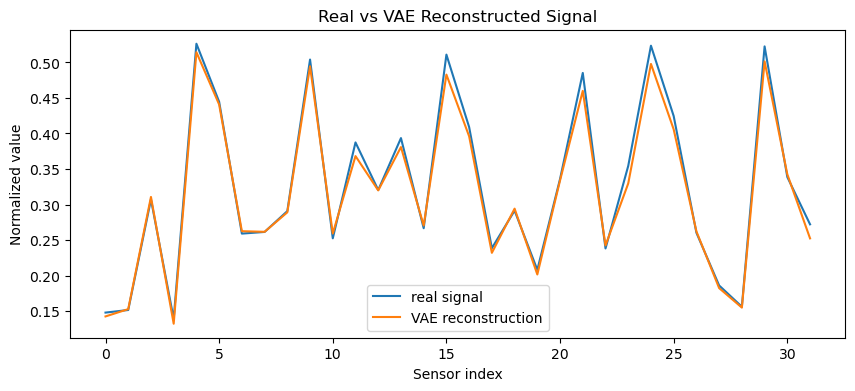

In [ ]:
import torch
import matplotlib.pyplot as plt

# Take one batch
images, signals = next(iter(val_loader))
images = images.to(device)
signals = signals.to(device)

coip_model.eval()
vae.eval()
denoising_model.eval()

with torch.no_grad():
    # Encode real signal with VAE
    mu, logvar = vae.encode(signals)
    recon = vae.decode(mu)

# Move to CPU
real_signal = signals[0].cpu().squeeze().numpy()
recon_signal = recon[0].cpu().squeeze().numpy()

plt.figure(figsize=(10, 4))
plt.plot(real_signal, label="real signal")
plt.plot(recon_signal, label="VAE reconstruction")
plt.legend()
plt.title("Real vs VAE Reconstructed Signal")
plt.xlabel("Sensor index")
plt.ylabel("Normalized value")
plt.show()

idx: 5386
image: ny_smells_local/images/sample_5386.jpg
signal: ny_smells_local/signals_raw/signal_5386.npy
object_idx                                 4
sample_start_idx                        5182
sample_end_idx                          5340
vision_idx                              5261
pid                                    64.19
temperature                             21.8
humidity                                33.9
global_id            2025-05-10_20-16-43_8_4
dist_to_object_cm                          0
scene_type           Upper Campus West Lawns
file_idx                                5386
Name: 5386, dtype: object
signal shape: (32,)
signal first values: [ 7.23454262e-05  1.20521901e-04  4.85324806e-04  1.51745788e-04
  7.42901162e-05 -1.24027384e-05  6.58618012e-04  4.21360889e-05
  6.94720384e-05  5.94332682e-05]


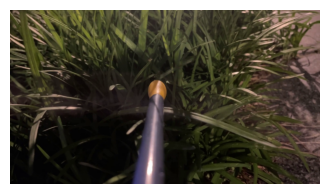

idx: 3733
image: ny_smells_local/images/sample_3733.jpg
signal: ny_smells_local/signals_raw/signal_3733.npy
object_idx                                      6
sample_start_idx                             7170
sample_end_idx                               7332
vision_idx                                   7251
pid                                         66.78
temperature                                  23.5
humidity                                     30.2
global_id                2025-04-28_15-34-42_13_6
dist_to_object_cm                               0
scene_type           Apartment Setting 1: Kitchen
file_idx                                     3733
Name: 3733, dtype: object
signal shape: (32,)
signal first values: [ 3.11789782e-07  2.59306051e-05  3.79987390e-04  1.46935349e-04
 -2.29842082e-04  7.12997168e-05  8.74020257e-05 -8.37170291e-06
 -1.01248131e-04 -5.30727833e-05]


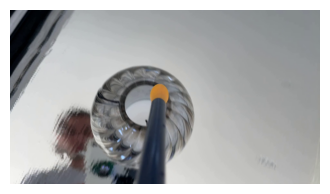

idx: 6299
image: ny_smells_local/images/sample_6299.jpg
signal: ny_smells_local/signals_raw/signal_6299.npy
object_idx                                   108
sample_start_idx                          118552
sample_end_idx                            118710
vision_idx                                118631
pid                                        64.55
temperature                                 25.8
humidity                                    40.0
global_id            2025-05-13_19-03-19_216_108
dist_to_object_cm                              0
scene_type                       Graphics Office
file_idx                                    6299
Name: 6299, dtype: object
signal shape: (32,)
signal first values: [-1.31173790e-05 -3.85981550e-06  4.09032551e-04 -2.79437717e-05
 -2.28123934e-04 -1.49970329e-04  4.03271000e-04 -4.87706018e-05
 -8.87325525e-05 -5.01011695e-05]


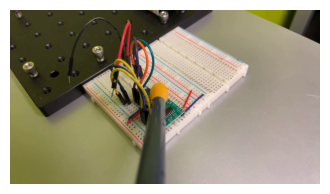

idx: 725
image: ny_smells_local/images/sample_0725.jpg
signal: ny_smells_local/signals_raw/signal_0725.npy
object_idx                                   80
sample_start_idx                          93671
sample_end_idx                            93829
vision_idx                                93750
pid                                       64.36
temperature                                25.1
humidity                                   25.1
global_id            2025-04-13_17-38-22_160_80
dist_to_object_cm                             0
scene_type                              Pupin 1
file_idx                                    725
Name: 725, dtype: object
signal shape: (32,)
signal first values: [0.00030241 0.00028788 0.04669328 0.00051806 0.00135946 0.00095918
 0.07930585 0.00029991 0.00045102 0.00029944]


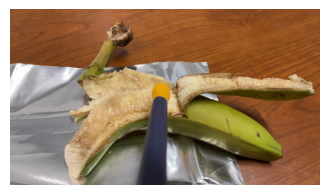

idx: 799
image: ny_smells_local/images/sample_0799.jpg
signal: ny_smells_local/signals_raw/signal_0799.npy
object_idx                                  40
sample_start_idx                         47878
sample_end_idx                           48036
vision_idx                               47957
pid                                      64.81
temperature                               24.4
humidity                                  28.3
global_id            2025-04-13_17-38-22_80_40
dist_to_object_cm                            0
scene_type                             Pupin 1
file_idx                                   799
Name: 799, dtype: object
signal shape: (32,)
signal first values: [-2.89690805e-05 -5.06367746e-05  6.59493981e-04 -4.74190762e-05
 -6.90738469e-04 -5.72617919e-04  6.52452821e-04 -9.46733877e-05
 -3.45409711e-05 -1.28718346e-04]


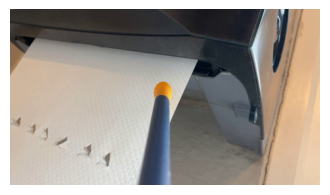

In [ ]:
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

df_check = pd.read_csv("ny_smells_local/metadata.csv")
df_check["file_idx"] = df_check.index

for _ in range(5):
    idx = random.randint(0, len(df_check) - 1)
    file_idx = df_check.loc[idx, "file_idx"]

    img_path = f"ny_smells_local/images/sample_{file_idx:04d}.jpg"
    sig_path = f"ny_smells_local/signals_raw/signal_{file_idx:04d}.npy"

    print("=" * 60)
    print("idx:", idx)
    print("image:", img_path)
    print("signal:", sig_path)
    print(df_check.iloc[idx])

    img = Image.open(img_path).convert("RGB")
    sig = np.load(sig_path)

    print("signal shape:", sig.shape)
    print("signal first values:", sig.reshape(-1)[:10])

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

signals shape: (200, 32)
overall std: 0.03845040908618057
mean sensor std: 0.01892954007605751
min: -0.08670801511263594 max: 0.8568739019448396


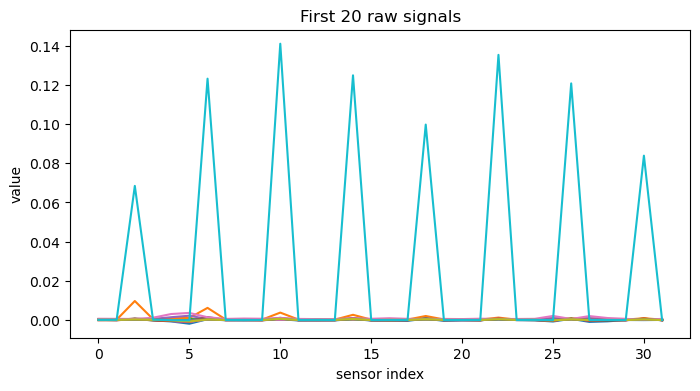

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt

signal_dir = "ny_smells_local/signals_raw"

signals = []

for i in range(200):
    path = os.path.join(signal_dir, f"signal_{i:04d}.npy")
    if os.path.exists(path):
        s = np.load(path).reshape(-1)
        signals.append(s)

signals = np.stack(signals)

print("signals shape:", signals.shape)
print("overall std:", signals.std())
print("mean sensor std:", signals.std(axis=0).mean())
print("min:", signals.min(), "max:", signals.max())

plt.figure(figsize=(8, 4))
plt.plot(signals[:20].T)
plt.title("First 20 raw signals")
plt.xlabel("sensor index")
plt.ylabel("value")
plt.show()

In [ ]:
import os
import numpy as np

SOURCE_DATASET_ROOT = "/Users/tonydemac/Downloads/olfactory_project/dataset"

shapes = {}

for root, dirs, files in os.walk(SOURCE_DATASET_ROOT):
    for f in files:
        if f.endswith(".npy"):
            path = os.path.join(root, f)
            try:
                arr = np.load(path)
                shapes[arr.shape] = shapes.get(arr.shape, 0) + 1
            except Exception as e:
                pass

print("Numpy shapes found:")
for shape, count in sorted(shapes.items(), key=lambda x: -x[1]):
    print(shape, count)

Numpy shapes found:
(18, 32) 6383
(768,) 5090
(17, 32) 3896
(16, 32) 2754
(15, 32) 831
(14, 32) 4


idx: 4734
image: ny_smells_local/images/sample_4734.jpg
signal: ny_smells_local/signals_raw/signal_4734.npy
object_idx                                 1
sample_start_idx                        1384
sample_end_idx                          1546
vision_idx                              1465
pid                                    64.79
temperature                             27.3
humidity                                49.2
global_id            2025-05-04_21-17-32_2_1
dist_to_object_cm                          0
scene_type                       shree's lab
file_idx                                4734
Name: 4734, dtype: object


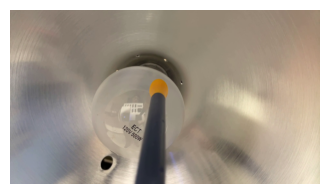

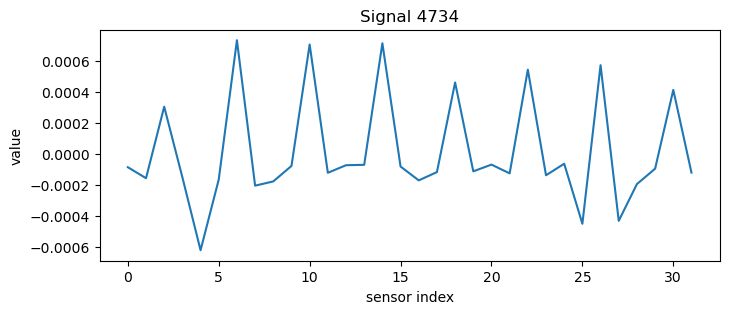

idx: 428
image: ny_smells_local/images/sample_0428.jpg
signal: ny_smells_local/signals_raw/signal_0428.npy
object_idx                                   80
sample_start_idx                          89764
sample_end_idx                            89922
vision_idx                                89843
pid                                       64.42
temperature                                22.6
humidity                                   27.5
global_id            2025-04-12_23-11-38_161_80
dist_to_object_cm                             0
scene_type                                CEPSR
file_idx                                    428
Name: 428, dtype: object


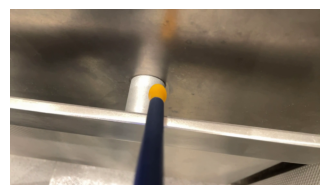

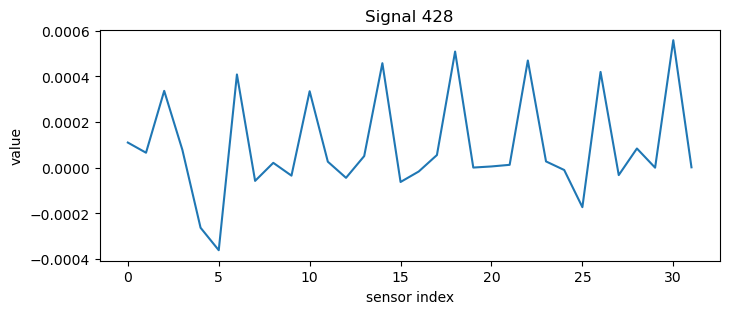

idx: 4995
image: ny_smells_local/images/sample_4995.jpg
signal: ny_smells_local/signals_raw/signal_4995.npy
object_idx                                   110
sample_start_idx                          138720
sample_end_idx                            138878
vision_idx                                138799
pid                                        64.43
temperature                                 23.5
humidity                                    43.4
global_id            2025-05-08_19-22-22_221_110
dist_to_object_cm                              0
scene_type                                 CEPSR
file_idx                                    4995
Name: 4995, dtype: object


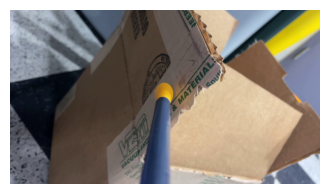

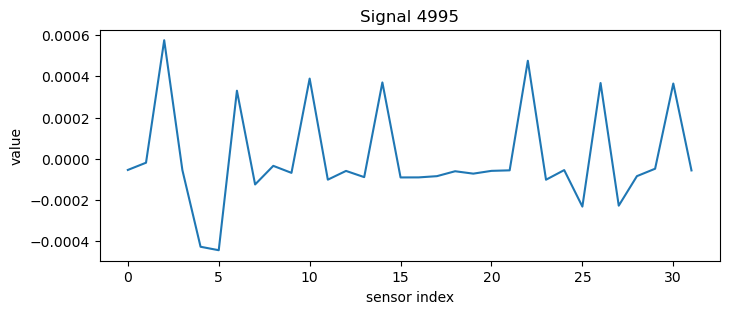

idx: 4911
image: ny_smells_local/images/sample_4911.jpg
signal: ny_smells_local/signals_raw/signal_4911.npy
object_idx                                   73
sample_start_idx                          95661
sample_end_idx                            95819
vision_idx                                95740
pid                                       64.38
temperature                                26.2
humidity                                   37.2
global_id            2025-05-08_19-22-22_146_73
dist_to_object_cm                             0
scene_type                                CEPSR
file_idx                                   4911
Name: 4911, dtype: object


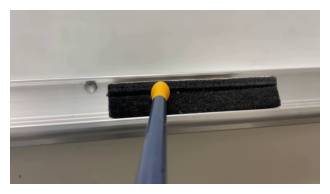

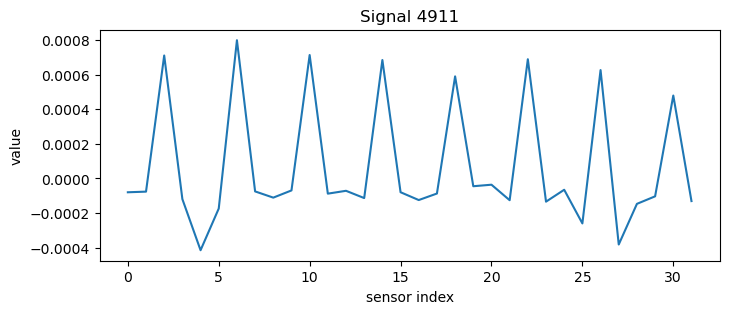

idx: 3347
image: ny_smells_local/images/sample_3347.jpg
signal: ny_smells_local/signals_raw/signal_3347.npy
object_idx                                       113
sample_start_idx                              121649
sample_end_idx                                121811
vision_idx                                    121730
pid                                            65.07
temperature                                     28.8
humidity                                        33.4
global_id                2025-04-25_14-03-32_227_113
dist_to_object_cm                                  0
scene_type           John Jay Dining Hall (Facility)
file_idx                                        3347
Name: 3347, dtype: object


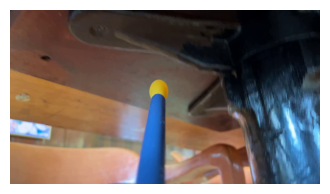

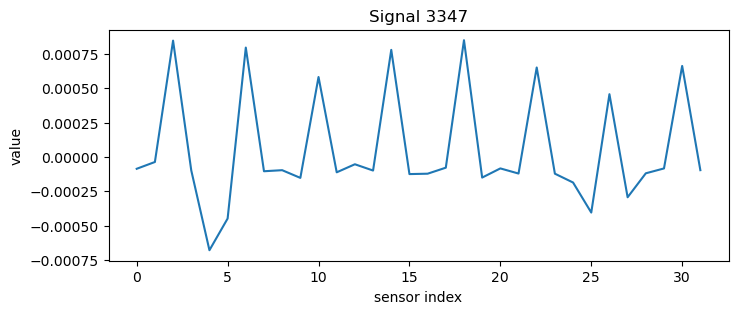

In [ ]:
import random
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import os

df_check = pd.read_csv("ny_smells_local/metadata.csv")
df_check["file_idx"] = df_check.index

for _ in range(5):
    idx = random.randint(0, len(df_check) - 1)
    file_idx = df_check.loc[idx, "file_idx"]

    img_path = f"ny_smells_local/images/sample_{file_idx:04d}.jpg"
    sig_path = f"ny_smells_local/signals_raw/signal_{file_idx:04d}.npy"

    print("=" * 60)
    print("idx:", idx)
    print("image:", img_path)
    print("signal:", sig_path)
    print(df_check.iloc[idx])

    img = Image.open(img_path).convert("RGB")
    sig = np.load(sig_path).reshape(-1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(8, 3))
    plt.plot(sig)
    plt.title(f"Signal {file_idx}")
    plt.xlabel("sensor index")
    plt.ylabel("value")
    plt.show()

In [ ]:
@torch.no_grad()
def validate_object_retrieval(model, val_loader, val_df, device):
    model.eval()

    all_img_emb = []
    all_sig_emb = []

    for images, signals in tqdm(val_loader, desc="Validating object-level retrieval"):
        images = images.to(device)
        signals = signals.to(device)

        img_emb, sig_emb, _ = model(images, signals)

        all_img_emb.append(img_emb.cpu())
        all_sig_emb.append(sig_emb.cpu())

    all_img_emb = torch.cat(all_img_emb, dim=0)
    all_sig_emb = torch.cat(all_sig_emb, dim=0)

    similarity = all_img_emb @ all_sig_emb.T
    ranking = similarity.argsort(dim=1, descending=True)

    object_ids = torch.tensor(val_df["object_idx"].values)

    correct_at_1 = 0
    correct_at_5 = 0

    for i in range(similarity.size(0)):
        true_object = object_ids[i]

        top1_idx = ranking[i, 0]
        top5_idx = ranking[i, :5]

        if object_ids[top1_idx] == true_object:
            correct_at_1 += 1

        if (object_ids[top5_idx] == true_object).any():
            correct_at_5 += 1

    return correct_at_1 / similarity.size(0), correct_at_5 / similarity.size(0)


obj_r1, obj_r5 = validate_object_retrieval(
    coip_model,
    val_loader,
    val_df,
    device
)

print("Object Recall@1:", obj_r1)
print("Object Recall@5:", obj_r5)

Validating object-level retrieval: 100%|██████████| 32/32 [00:25<00:00,  1.27it/s]


Object Recall@1: 0.068
Object Recall@5: 0.398


QUERY
query index: 0
query file_idx: 5925
query object_idx: 57
image path: ny_smells_local/images/sample_5925.jpg


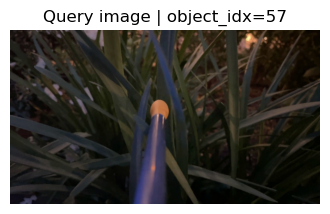

Top-5 retrieved signals:
Rank 1: val_index=421, object_idx=90, score=0.5350, correct_object=False
Rank 2: val_index=212, object_idx=5, score=0.5315, correct_object=False
Rank 3: val_index=403, object_idx=107, score=0.5304, correct_object=False
Rank 4: val_index=321, object_idx=57, score=0.5292, correct_object=True
Rank 5: val_index=66, object_idx=5, score=0.5263, correct_object=False


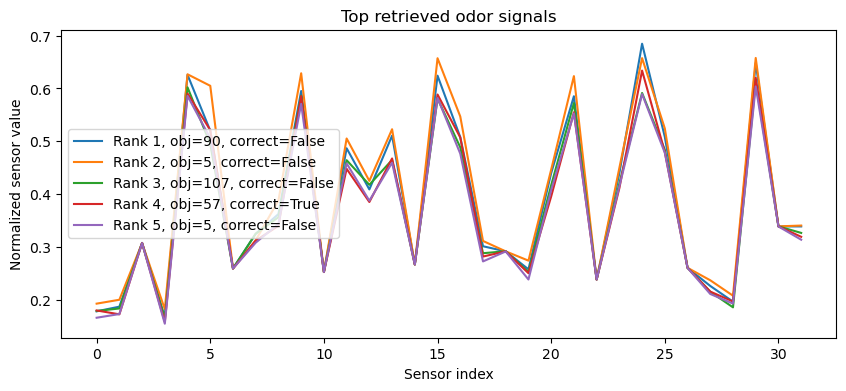

In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

@torch.no_grad()
def show_image_to_signal_retrieval(
    model=coip_model,
    val_dataset=val_dataset,
    val_loader=val_loader,
    val_df=val_df,
    device=device,
    query_index=10,
    top_k=5
):
    model.eval()

    # ----------------------------
    # 1. Encode all validation signals
    # ----------------------------
    all_sig_emb = []
    all_object_ids = []

    for images, signals, object_ids in val_loader:
        signals = signals.to(device)

        # We only need signal embeddings here
        dummy_images = images.to(device)
        _, sig_emb, _ = model(dummy_images, signals)

        all_sig_emb.append(sig_emb.cpu())
        all_object_ids.append(object_ids.cpu())

    all_sig_emb = torch.cat(all_sig_emb, dim=0)
    all_object_ids = torch.cat(all_object_ids, dim=0)

    # ----------------------------
    # 2. Get query image
    # ----------------------------
    pixel_values, query_signal, query_object_id = val_dataset[query_index]

    pixel_values_batch = pixel_values.unsqueeze(0).to(device)
    query_signal_batch = query_signal.unsqueeze(0).to(device)

    img_emb, _, _ = model(pixel_values_batch, query_signal_batch)
    img_emb = img_emb.cpu()

    # ----------------------------
    # 3. Similarity search
    # ----------------------------
    similarity = img_emb @ all_sig_emb.T
    top_scores, top_indices = torch.topk(similarity[0], k=top_k)

    # ----------------------------
    # 4. Show query image
    # ----------------------------
    file_idx = int(val_df.iloc[query_index]["file_idx"])
    img_path = os.path.join("ny_smells_local/images", f"sample_{file_idx:04d}.jpg")

    image = Image.open(img_path).convert("RGB")

    print("=" * 60)
    print("QUERY")
    print("query index:", query_index)
    print("query file_idx:", file_idx)
    print("query object_idx:", int(query_object_id))
    print("image path:", img_path)

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Query image | object_idx={int(query_object_id)}")
    plt.axis("off")
    plt.show()

    # ----------------------------
    # 5. Show top-k results
    # ----------------------------
    print("=" * 60)
    print(f"Top-{top_k} retrieved signals:")

    plt.figure(figsize=(10, 4))

    for rank, idx in enumerate(top_indices):
        idx = int(idx)
        score = float(top_scores[rank])
        retrieved_object_id = int(all_object_ids[idx])

        is_correct = retrieved_object_id == int(query_object_id)

        print(
            f"Rank {rank+1}: "
            f"val_index={idx}, "
            f"object_idx={retrieved_object_id}, "
            f"score={score:.4f}, "
            f"correct_object={is_correct}"
        )

        _, retrieved_signal, _ = val_dataset[idx]
        retrieved_signal = retrieved_signal.squeeze().numpy()

        plt.plot(
            retrieved_signal,
            label=f"Rank {rank+1}, obj={retrieved_object_id}, correct={is_correct}"
        )

    plt.title("Top retrieved odor signals")
    plt.xlabel("Sensor index")
    plt.ylabel("Normalized sensor value")
    plt.legend()
    plt.show()


show_image_to_signal_retrieval(
    model=coip_model,
    val_dataset=val_dataset,
    val_loader=val_loader,
    val_df=val_df,
    device=device,
    query_index=0,
    top_k=5
)

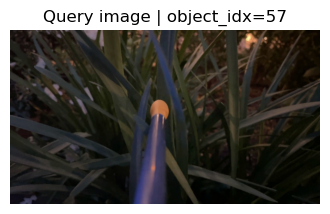

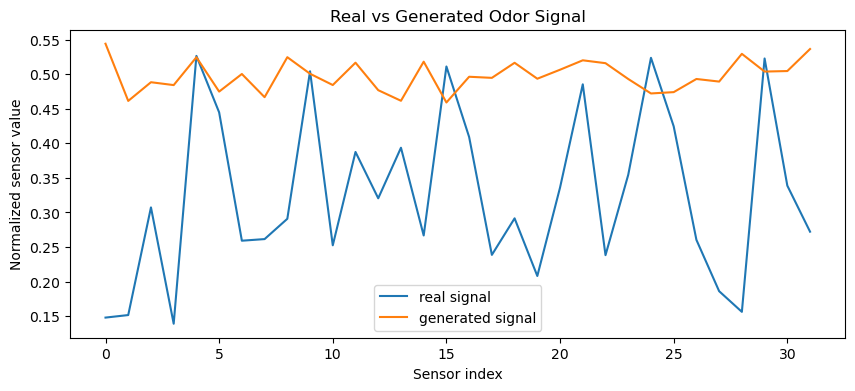

object_idx: 57
real signal: [0.14792192 0.1515821  0.30725864 0.13905089 0.52635366 0.4446641
 0.2590977  0.2614341  0.2907867  0.5040664  0.25243902 0.3874253
 0.3204177  0.39354315 0.2666439  0.5110293  0.40900293 0.23860855
 0.2914453  0.20807944 0.3359893  0.48526493 0.23819661 0.35434642
 0.5235628  0.42450726 0.26032636 0.18609524 0.15621936 0.5225907
 0.3387037  0.27213815]
generated signal: [0.54394543 0.4612355  0.48827627 0.48412773 0.5243977  0.47473198
 0.50017405 0.46663868 0.52447325 0.50051636 0.4842067  0.5165189
 0.47677183 0.46144363 0.5179702  0.45897284 0.49618003 0.49458525
 0.5163764  0.49334037 0.50635314 0.5199598  0.5158052  0.49293256
 0.47202918 0.47394153 0.49295595 0.4892099  0.52930385 0.50367326
 0.5044354  0.53629845]


In [ ]:
@torch.no_grad()
def generate_signal_from_image(
    image_tensor,
    coip_model,
    denoising_model,
    vae,
    device,
    latent_dim=128,
    steps=50
):
    coip_model.eval()
    denoising_model.eval()
    vae.eval()

    image_tensor = image_tensor.to(device)

    # 1. Get image embedding
    image_features = coip_model.vision_encoder(image_tensor)
    image_features = F.normalize(image_features, dim=-1)

    batch_size = image_tensor.size(0)

    # 2. Start from random latent noise
    z_t = torch.randn(batch_size, latent_dim, device=device)

    # 3. Iterative denoising
    for i in reversed(range(steps)):
        t_value = i / steps
        t = torch.full((batch_size, 1), t_value, device=device)

        predicted_noise = denoising_model(z_t, t, image_features)

        z_t = z_t - predicted_noise / steps

    # 4. Decode latent to signal
    generated_signal = vae.decode(z_t)

    return generated_signal


@torch.no_grad()
def show_generated_signal_for_image(
    query_index=0,
    steps=50
):
    pixel_values, real_signal, object_id = val_dataset[query_index]

    image_batch = pixel_values.unsqueeze(0).to(device)

    generated_signal = generate_signal_from_image(
        image_tensor=image_batch,
        coip_model=coip_model,
        denoising_model=denoising_model,
        vae=vae,
        device=device,
        latent_dim=SIGNAL_LATENT_DIM,
        steps=steps
    )

    real_signal_np = real_signal.squeeze().cpu().numpy()
    generated_signal_np = generated_signal[0].squeeze().cpu().numpy()

    file_idx = int(val_df.iloc[query_index]["file_idx"])
    img_path = os.path.join("ny_smells_local/images", f"sample_{file_idx:04d}.jpg")
    image = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.title(f"Query image | object_idx={int(object_id)}")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(real_signal_np, label="real signal")
    plt.plot(generated_signal_np, label="generated signal")
    plt.title("Real vs Generated Odor Signal")
    plt.xlabel("Sensor index")
    plt.ylabel("Normalized sensor value")
    plt.legend()
    plt.show()

    print("object_idx:", int(object_id))
    print("real signal:", real_signal_np)
    print("generated signal:", generated_signal_np)


show_generated_signal_for_image(
    query_index=0,
    steps=50
)

In [ ]:
import torch
import torch.nn as nn
from transformers import ViTModel

VIT_MODEL_NAME = "google/vit-base-patch16-224"


class VisionEncoder(nn.Module):
    def __init__(self, latent_dim=512, model_name=VIT_MODEL_NAME):
        super().__init__()

        self.backbone = ViTModel.from_pretrained(model_name)

        self.projection = nn.Sequential(
            nn.Linear(self.backbone.config.hidden_size, 1024),
            nn.GELU(),
            nn.Linear(1024, latent_dim),
            nn.LayerNorm(latent_dim)
        )

    def forward(self, pixel_values):
        outputs = self.backbone(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]
        latent_vector = self.projection(cls_token)
        return latent_vector


class SignalVAE(nn.Module):
    def __init__(self, latent_dim=128, signal_length=1):
        super().__init__()

        self.latent_dim = latent_dim
        self.signal_length = signal_length

        self.encoder = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(64, 128, kernel_size=1),
            nn.GELU(),
            nn.AdaptiveAvgPool1d(1)
        )

        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        self.decoder_fc = nn.Linear(latent_dim, 128 * signal_length)

        self.decoder = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(64, 32, kernel_size=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        x = self.encoder(x)
        x = x.squeeze(-1)

        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)

        return mu + eps * std

    def decode(self, z):
        x = self.decoder_fc(z)
        x = x.view(z.size(0), 128, self.signal_length)
        x = self.decoder(x)

        return x

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)

        return recon, mu, logvar


class LatentDenoisingModel(nn.Module):
    def __init__(self, latent_dim=128, cond_dim=512):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(latent_dim + cond_dim + 1, 512),
            nn.GELU(),
            nn.Linear(512, 512),
            nn.GELU(),
            nn.Linear(512, latent_dim)
        )

    def forward(self, z_t, t, condition):
        if t.dim() == 1:
            t = t.unsqueeze(-1)

        t = t.float().to(z_t.device)
        condition = condition.to(z_t.device)

        x = torch.cat([z_t, t, condition], dim=-1)

        return self.net(x)

In [ ]:
import torch
import numpy as np
from PIL import Image
from torchvision import transforms
import torch.nn as nn


class ScentInferenceSystem:
    def __init__(self, weight_paths, fragrance_db, scheduler, meta_path, device="cuda"):
        """
        weight_paths:
            {
                "vae": "signal_vae.pt",
                "vision": "coip_model.pt",
                "unet": "latent_denoising_model.pt"
            }

        fragrance_db:
            Dictionary of {name: signal_numpy_array}, where each signal has shape (32, T).

        meta_path:
            Path to sensor_metadata.pt containing "min" and "max" tensors.
        """
        self.device = device
        self.gallery = fragrance_db
        self.scheduler = scheduler

        # Load sensor normalization constants
        meta = torch.load(meta_path, map_location=self.device)
        self.s_min = meta["min"].to(self.device)
        self.s_max = meta["max"].to(self.device)

        # Load trained models
        self.vision_encoder = self._prepare_model(
            VisionEncoder(),
            weight_paths["vision"]
        )

        self.vae_decoder = self._prepare_model(
            SignalVAE(),
            weight_paths["vae"],
            mode="decoder_only"
        )

        self.diffusion_unet = self._prepare_model(
            LatentDenoisingModel(),
            weight_paths["unet"]
        )

        # Image preprocessing for ViT
        self.preprocess = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            ),
        ])

    def _prepare_model(self, model, path, mode="full"):
        checkpoint = torch.load(path, map_location=self.device)

        if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
            state_dict = checkpoint["model_state_dict"]
        else:
            state_dict = checkpoint

        # coip_model.pt saves the whole COIPModel.
        # For VisionEncoder, keep only keys beginning with "vision_encoder."
        if isinstance(model, VisionEncoder):
            state_dict = {
                k.replace("vision_encoder.", ""): v
                for k, v in state_dict.items()
                if k.startswith("vision_encoder.")
            }

        model.load_state_dict(state_dict, strict=True)

        return model.to(self.device).eval()

    @torch.no_grad()
    def predict_scent(self, image_path, guidance_scale=3.5):
        # A. Vision stream
        img = Image.open(image_path).convert("RGB")
        img_t = self.preprocess(img).unsqueeze(0).to(self.device)

        image_emb = self.vision_encoder(img_t)

        # B. Diffusion stream
        z = torch.randn(1, 128).to(self.device)

        for t in self.scheduler.timesteps:
            t_tensor = torch.tensor([t], device=self.device).float().view(1, 1)

            eps = self.diffusion_unet(z, t_tensor, image_emb)

            z = self.scheduler.step(eps, t, z).prev_sample

        # C. VAE reconstruction
        generated_signal = self.vae_decoder.decode(z)

        # D. Denormalize to real sensor voltage scale
        final_signal = generated_signal * (self.s_max - self.s_min + 1e-8) + self.s_min
        final_signal_np = final_signal.squeeze(0).cpu().numpy()

        # E. Match generated signal with fragrance database
        recommendation, score = self._match_fragrance(final_signal_np)

        self._display_report(image_path, recommendation, score)

        return recommendation, score, final_signal_np

    def _match_fragrance(self, gen_signal):
        best_name = "Unknown"
        max_sim = -1.0

        gen_vec = gen_signal.flatten()

        for name, ref_signal in self.gallery.items():
            ref_vec = ref_signal.flatten()

            sim = np.dot(gen_vec, ref_vec) / (
                np.linalg.norm(gen_vec) * np.linalg.norm(ref_vec) + 1e-8
            )

            if sim > max_sim:
                max_sim = sim
                best_name = name

        return best_name, float(max_sim)

    def _display_report(self, path, name, score):
        print("\n" + "=" * 40)
        print("ENVIRONMENTAL SCENT RECONSTRUCTION")
        print("=" * 40)
        print(f"INPUT IMAGE: {path}")
        print(f"RECONSTRUCTED FRAGRANCE: {name.upper()}")
        print(f"CONFIDENCE (COSINE SIM): {score:.4f}")
        print("-" * 40)

        if score > 0.85:
            print("STATUS: High-fidelity chemical match found.")
        elif score > 0.60:
            print("STATUS: Semantic match established.")
        else:
            print("STATUS: Low confidence. Scent may be unique to environment.")

        print("=" * 40 + "\n")

In [ ]:
import os
import numpy as np
import pandas as pd

metadata_csv = "ny_smells_local/metadata.csv"
signal_dir = "ny_smells_local/signals_raw"

df = pd.read_csv(metadata_csv)

fragrance_db = {}

for idx, row in df.iterrows():
    sig_path = os.path.join(signal_dir, f"signal_{idx:04d}.npy")

    if os.path.exists(sig_path):
        signal = np.load(sig_path)

        # Make sure shape is (32, T)
        if signal.shape[0] != 32:
            signal = signal.T

        fragrance_db[f"sample_{idx:04d}"] = signal

print("Loaded fragrance samples:", len(fragrance_db))

first_key = list(fragrance_db.keys())[0]
print("Example name:", first_key)
print("Example shape:", fragrance_db[first_key].shape)

Loaded fragrance samples: 6934
Example name: sample_0000
Example shape: (32,)


In [ ]:
from diffusers import DDPMScheduler
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

weight_paths = {
    "vae": "signal_vae.pt",
    "vision": "coip_model.pt",
    "unet": "latent_denoising_model.pt"
}

meta_path = "sensor_metadata.pt"

scheduler = DDPMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(50)

scent_system = ScentInferenceSystem(
    weight_paths=weight_paths,
    fragrance_db=fragrance_db,
    scheduler=scheduler,
    meta_path=meta_path,
    device=device
)

recommendation, score, generated_signal = scent_system.predict_scent(
    image_path="ny_smells_local/images/sample_0000.jpg",
    guidance_scale=3.5
)

print("Recommended fragrance:", recommendation)
print("Score:", score)
print("Generated signal shape:", generated_signal.shape)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 13202.64it/s]
[transformers] ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.weight   | UNEXPECTED | 
classifier.bias     | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



ENVIRONMENTAL SCENT RECONSTRUCTION
INPUT IMAGE: ny_smells_local/images/sample_0000.jpg
RECONSTRUCTED FRAGRANCE: SAMPLE_1099
CONFIDENCE (COSINE SIM): 0.9930
----------------------------------------
STATUS: High-fidelity chemical match found.

Recommended fragrance: sample_1099
Score: 0.9930456682273501
Generated signal shape: (32, 1)
